In [30]:
import pandas as pd
import numpy as np
import re

In [12]:
df = pd.read_csv(
    "data/data.csv",
    encoding="utf-8",
    encoding_errors="ignore"
)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Company Names              1218 non-null   str  
 1   Cars Names                 1218 non-null   str  
 2   Engines                    1218 non-null   str  
 3   CC/Battery Capacity        1215 non-null   str  
 4   HorsePower                 1218 non-null   str  
 5   Total Speed                1218 non-null   str  
 6   Performance(0 - 100 )KM/H  1212 non-null   str  
 7   Cars Prices                1218 non-null   str  
 8   Fuel Types                 1218 non-null   str  
 9   Seats                      1218 non-null   str  
 10  Torque                     1217 non-null   str  
dtypes: str(11)
memory usage: 208.9 KB


In [14]:
#color
# brand
# price
# highspeed
# transmission


In [15]:
df.describe()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
count,1218,1218,1218,1215,1218,1218,1212,1218,1218,1218,1217
unique,37,1201,356,311,456,114,180,535,23,19,263
top,Nissan,KA+,I4,"2,000 cc",355 hp,250 km/h,6.5 sec,"$35,000",Petrol,5,400 Nm
freq,149,2,64,31,23,145,45,36,871,692,72


In [16]:
df.isnull().sum()

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       1
dtype: int64

In [17]:
df.shape

(1218, 11)

In [18]:
df.columns = [
    "brand",
    "car_name",
    "engine",
    "battery_capacity",
    "horsepower",
    "top_speed",
    "acceleration_0_100",
    "price",
    "fuel_type",
    "seats",
    "torque"
]

In [19]:
df["torque"].fillna(df["torque"].mode()[0], inplace=True)

C:\Users\Yassine KERFAI\AppData\Local\Temp\ipykernel_18440\1380265208.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["torque"].fillna(df["torque"].mode()[0], inplace=True)


0             800 Nm
1             900 Nm
2       100 - 140 Nm
3             900 Nm
4             560 Nm
            ...     
1213          239 Nm
1214          630 Nm
1215     190  210 Nm
1216     190  205 Nm
1217     221  400 Nm
Name: torque, Length: 1218, dtype: str

In [20]:
df.dropna(inplace=True)

In [21]:
df["horsepower"] = (
    df["horsepower"]
    .str.replace(" hp", "", regex=False)
    .astype(int)
)

ValueError: invalid literal for int() with base 10: '70-85'

In [22]:
df["top_speed"] = (
    df["top_speed"]
    .str.replace(" km/h", "", regex=False)
    .astype(int)
)

In [23]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

ValueError: invalid literal for int() with base 10: '12000-15000'

In [24]:
df["acceleration_0_100"] = (
    df["acceleration_0_100"]
    .str.replace(" sec", "", regex=False)
    .astype(float)
)

ValueError: could not convert string to float: '5. 0'

In [25]:
df["torque"] = (
    df["torque"]
    .str.replace(" Nm", "", regex=False)
    .astype(int)
)

ValueError: invalid literal for int() with base 10: '100 - 140'

In [26]:
df["seats"] = df["seats"].astype(int)

ValueError: invalid literal for int() with base 10: '2+2'

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 1210 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   brand               1210 non-null   str  
 1   car_name            1210 non-null   str  
 2   engine              1210 non-null   str  
 3   battery_capacity    1210 non-null   str  
 4   horsepower          1210 non-null   str  
 5   top_speed           1210 non-null   int64
 6   acceleration_0_100  1210 non-null   str  
 7   price               1210 non-null   str  
 8   fuel_type           1210 non-null   str  
 9   seats               1210 non-null   str  
 10  torque              1210 non-null   str  
dtypes: int64(1), str(10)
memory usage: 208.5 KB


In [28]:
df.duplicated().sum()

np.int64(4)

In [29]:
df.drop_duplicates(inplace=True)

In [31]:
def clean_numeric(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # fix weird decimal spacing
    value = value.replace(". ", ".")

    # remove commas and dollar signs
    value = value.replace(",", "")
    value = value.replace("$", "")

    # handle ranges like 70-85 or 100 - 140
    if "-" in value:

        parts = re.findall(r"\d+\.?\d*", value)

        if len(parts) >= 2:
            nums = [float(x) for x in parts]
            return sum(nums) / len(nums)

    # handle seat format like 2+2
    if "+" in value:

        parts = re.findall(r"\d+", value)

        if len(parts) >= 2:
            nums = [int(x) for x in parts]
            return sum(nums)

    # extract first numeric value
    match = re.search(r"\d+\.?\d*", value)

    if match:
        return float(match.group())

    return np.nan

In [32]:
df["horsepower"] = df["horsepower"].apply(clean_numeric)

In [33]:
df["top_speed"] = df["top_speed"].apply(clean_numeric)

In [34]:
df["top_speed"] = df["top_speed"].apply(clean_numeric)

In [35]:
df["price"] = df["price"].apply(clean_numeric)

In [36]:
df["acceleration_0_100"] = (
    df["acceleration_0_100"]
    .apply(clean_numeric)
)

In [37]:
df["torque"] = df["torque"].apply(clean_numeric)

In [38]:
df["seats"] = df["seats"].apply(clean_numeric)

In [39]:
numeric_cols = [
    "horsepower",
    "top_speed",
    "price",
    "acceleration_0_100",
    "torque",
    "seats"
]

df[numeric_cols] = df[numeric_cols].astype(float)

In [40]:
df[numeric_cols].head()

,horsepower,top_speed,price,acceleration_0_100,torque,seats
0,963.0,340.0,1100000.0,2.5,800.0,2.0
1,563.0,250.0,460000.0,5.3,900.0,5.0
2,77.5,165.0,13500.0,10.5,120.0,5.0
3,630.0,250.0,161000.0,3.2,900.0,4.0
4,602.0,320.0,253290.0,3.6,560.0,2.0


In [41]:
df.info()

<class 'pandas.DataFrame'>
Index: 1206 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   brand               1206 non-null   str    
 1   car_name            1206 non-null   str    
 2   engine              1206 non-null   str    
 3   battery_capacity    1206 non-null   str    
 4   horsepower          1206 non-null   float64
 5   top_speed           1206 non-null   float64
 6   acceleration_0_100  1206 non-null   float64
 7   price               1206 non-null   float64
 8   fuel_type           1206 non-null   str    
 9   seats               1206 non-null   float64
 10  torque              1206 non-null   float64
dtypes: float64(6), str(5)
memory usage: 171.5 KB


In [42]:
df.describe()

,horsepower,top_speed,acceleration_0_100,price,seats,torque
count,1206.000000,1206.000000,1206.000000,1.206000e+03,1206.000000,1206.000000
mean,306.101575,216.965174,7.565796,1.388455e+05,5.323383,507.703151
std,214.024215,52.722011,3.310581,7.142252e+05,8.947606,1054.021861
min,26.000000,80.000000,1.900000,4.000000e+03,1.000000,45.000000
25%,154.000000,180.000000,5.225000,2.800000e+04,4.000000,250.000000
50%,255.000000,200.000000,7.100000,4.264750e+04,5.000000,370.000000
75%,400.000000,250.000000,9.500000,7.000000e+04,5.000000,560.000000
max,1850.000000,500.000000,35.000000,1.800000e+07,215.000000,15590.000000


In [43]:
df.shape

(1206, 11)

In [44]:
df.duplicated().sum()

np.int64(1)

In [45]:
df.drop_duplicates(inplace=True)

In [46]:
df["car_name"].duplicated().sum()

np.int64(12)

In [47]:
df["brand"] = (
    df["brand"]
    .str.strip()
    .str.lower()
)

In [48]:
df["fuel_type"] = (
    df["fuel_type"]
    .str.strip()
    .str.lower()
)

In [49]:
df["engine"] = (
    df["engine"]
    .str.strip()
    .str.upper()
)

In [50]:
df.describe()

,horsepower,top_speed,acceleration_0_100,price,seats,torque
count,1205.000000,1205.000000,1205.000000,1.205000e+03,1205.000000,1205.000000
mean,306.291286,217.008299,7.563361,1.389495e+05,5.323651,508.024896
std,214.011611,52.722617,3.310875,7.145126e+05,8.951316,1054.400237
min,26.000000,80.000000,1.900000,4.000000e+03,1.000000,45.000000
25%,154.000000,180.000000,5.200000,2.800000e+04,4.000000,250.000000
50%,255.000000,200.000000,7.100000,4.279500e+04,5.000000,370.000000
75%,400.000000,250.000000,9.500000,7.000000e+04,5.000000,560.000000
max,1850.000000,500.000000,35.000000,1.800000e+07,215.000000,15590.000000


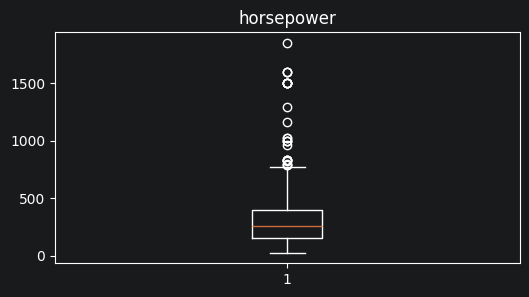

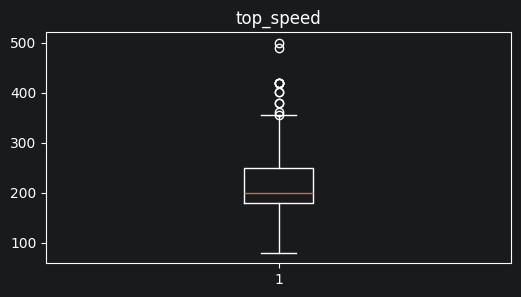

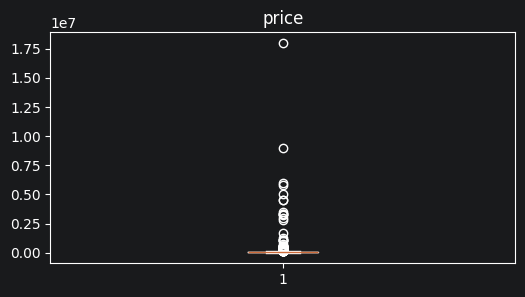

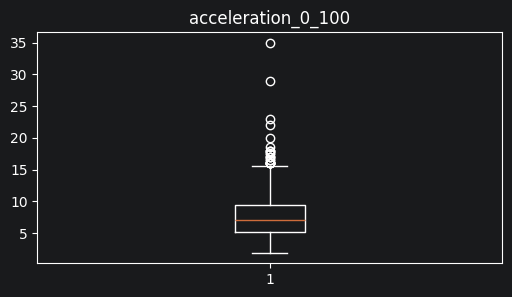

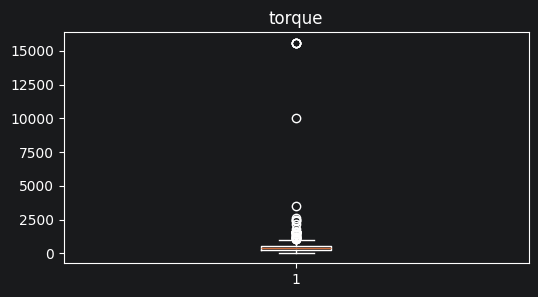

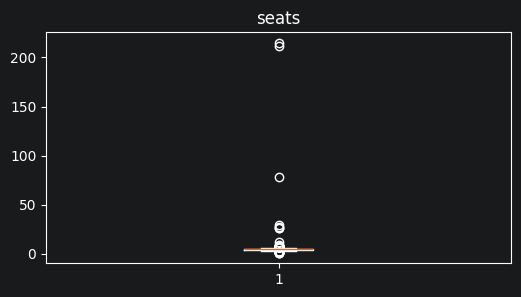

In [51]:
import matplotlib.pyplot as plt

numeric_cols = [
    "horsepower",
    "top_speed",
    "price",
    "acceleration_0_100",
    "torque",
    "seats"
]

for col in numeric_cols:

    plt.figure(figsize=(6,3))

    plt.boxplot(df[col])

    plt.title(col)

    plt.show()

In [52]:
df = df[df["price"] > 1000]

df = df[df["horsepower"] > 20]

df = df[df["top_speed"] > 50]

df = df[df["seats"] <= 10]

In [53]:
df.shape

(1197, 11)

In [54]:
df["fuel_type"].value_counts()

fuel_type
petrol                     865
diesel                      98
electric                    93
hybrid                      78
petrol/diesel               16
petrol/hybrid               16
plug-in hybrid               5
diesel/petrol                4
hybrid (petrol)              4
hydrogen                     3
petrol, diesel               3
petrol/awd                   2
petrol, hybrid               2
plug in hyrbrid              1
petrol/ev                    1
hybrid/electric              1
cng/petrol                   1
hybrid/petrol                1
hybrid (gas + electric)      1
gas / hybrid                 1
hybrid / plug-in             1
Name: count, dtype: int64

In [55]:
df = df[
    (df["seats"] <= 10) &
    (df["horsepower"] <= 1500) &
    (df["top_speed"] <= 450) &
    (df["torque"] <= 3000) &
    (df["price"] <= 1000000) &
    (df["acceleration_0_100"] <= 20)
]

In [56]:
df.shape

(1166, 11)

In [57]:
df["fuel_type"] = df["fuel_type"].replace({

    "petrol/diesel": "hybrid",
    "diesel/petrol": "hybrid",
    "petrol/hybrid": "hybrid",
    "hybrid (petrol)": "hybrid",
    "plug-in hybrid": "hybrid"

})

In [58]:
df["fuel_type"].value_counts()

fuel_type
petrol                     846
hybrid                     120
diesel                      96
electric                    87
hydrogen                     3
petrol, diesel               3
petrol/awd                   2
petrol, hybrid               2
petrol/ev                    1
hybrid/electric              1
cng/petrol                   1
hybrid/petrol                1
hybrid (gas + electric)      1
gas / hybrid                 1
hybrid / plug-in             1
Name: count, dtype: int64

In [59]:
df["fuel_type"] = (
    df["fuel_type"]
    .str.lower()
    .str.strip()
)

In [60]:
df["fuel_type"] = df["fuel_type"].replace({

    # hybrid variants
    "petrol/diesel": "hybrid",
    "diesel/petrol": "hybrid",
    "petrol/hybrid": "hybrid",
    "petrol, hybrid": "hybrid",
    "hybrid (petrol)": "hybrid",
    "plug-in hybrid": "hybrid",
    "hybrid/electric": "hybrid",
    "petrol/ev": "hybrid",

    # petrol variants
    "petrol, diesel": "petrol",
    "petrol/awd": "petrol"

})

In [61]:
df["fuel_type"].value_counts()

fuel_type
petrol                     851
hybrid                     124
diesel                      96
electric                    87
hydrogen                     3
cng/petrol                   1
hybrid/petrol                1
hybrid (gas + electric)      1
gas / hybrid                 1
hybrid / plug-in             1
Name: count, dtype: int64

In [62]:
df["fuel_type"] = df["fuel_type"].replace({

    "cng/petrol": "hybrid",
    "hybrid/petrol": "hybrid",
    "hybrid (gas + electric)": "hybrid",
    "gas / hybrid": "hybrid",
    "hybrid / plug-in": "hybrid"

})

In [63]:
df.shape

(1166, 11)

In [64]:
df["fuel_type"].value_counts()

fuel_type
petrol      851
hybrid      129
diesel       96
electric     87
hydrogen      3
Name: count, dtype: int64

In [65]:
df.select_dtypes(include="object").head()

C:\Users\Yassine KERFAI\AppData\Local\Temp\ipykernel_18440\2301917015.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").head()


,brand,car_name,engine,battery_capacity,fuel_type
1,rolls royce,PHANTOM,V12,6749 cc,petrol
2,ford,KA+,1.2L PETROL,"1,200 cc",petrol
3,mercedes,GT 63 S,V8,"3,982 cc",petrol
4,audi,AUDI R8 Gt,V10,"5,204 cc",petrol
5,bmw,Mclaren 720s,V8,"3,994 cc",petrol


In [66]:
df.info()

<class 'pandas.DataFrame'>
Index: 1166 entries, 1 to 1217
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   brand               1166 non-null   str    
 1   car_name            1166 non-null   str    
 2   engine              1166 non-null   str    
 3   battery_capacity    1166 non-null   str    
 4   horsepower          1166 non-null   float64
 5   top_speed           1166 non-null   float64
 6   acceleration_0_100  1166 non-null   float64
 7   price               1166 non-null   float64
 8   fuel_type           1166 non-null   str    
 9   seats               1166 non-null   float64
 10  torque              1166 non-null   float64
dtypes: float64(6), str(5)
memory usage: 165.1 KB


In [67]:
df_corr = df[
    [
        "horsepower",
        "top_speed",
        "acceleration_0_100",
        "price",
        "torque",
        "seats"
    ]
]

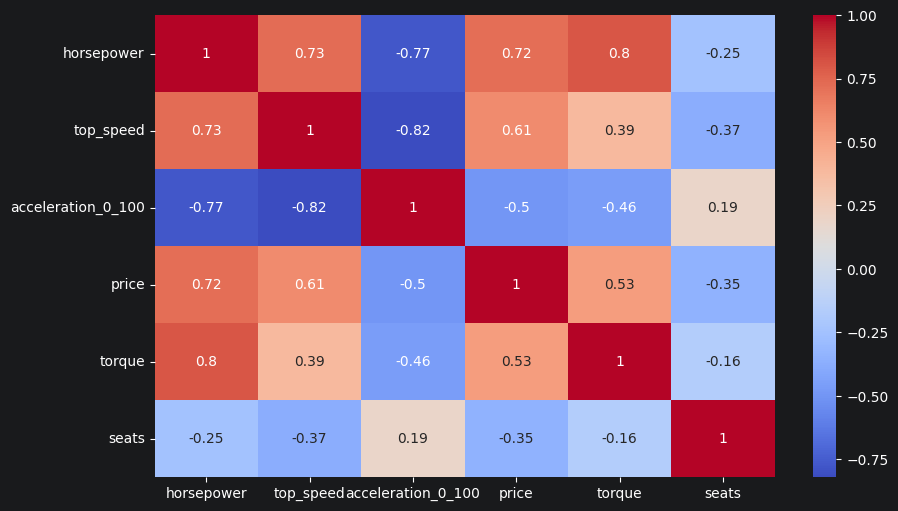

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [69]:
df["performance_score"] = (
    df["horsepower"] *
    df["top_speed"]
) / df["acceleration_0_100"]

In [70]:
df["value_score"] = (
    df["horsepower"] /
    df["price"]
)

In [71]:
df["luxury_score"] = (
    df["price"] *
    df["top_speed"]
)

In [72]:
df_encoded = pd.get_dummies(
    df,
    columns=["brand", "fuel_type"],
    drop_first=True
)

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = [
    "horsepower",
    "top_speed",
    "acceleration_0_100",
    "price",
    "torque",
    "seats",
    "performance_score",
    "value_score"
]

df_encoded[numerical_cols] = scaler.fit_transform(
    df_encoded[numerical_cols]
)

In [74]:
features = df_encoded.drop(
    columns=[
        "car_name",
        "engine",
        "battery_capacity"
    ]
)